## Dataset visualization and statistics

This notebook displays visualizations and statistics for the MRI datasets

In [1]:
from pathlib import Path
import random

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import re
from IPython.display import HTML, display

from monai.transforms import Resize, ResizeWithPadOrCrop

### 1 Statistics

Section for different statistics

#### 1.1 Dataset statistics

LIST ALL TABLES THAT CAN BE FOUND IN THIS SECTION HERE

In [2]:
# Section for dataset statistics
    # Total number of patient in the real datasets
        # Total number of slices with and without tumor
    # Total number of slices in the synthetic data
    # Visulization of the distribution of slices with and without tumor in the real datasets

    # Statistics of relationship between real and synthetic masks (?)
    # Statistics of relationship between real ans synthetic images (?)

In [3]:
dataset_statistics = pd.DataFrame(
    {
        "Dataset": ["real train", "real test", "synthetic"],
        "Patient count": [105, 51, None],
        "Total slice count": [15952, 7696, 37624],
        "Slices with tumor count": [3823, 2086, 37624],
    }
)

print("All dataset statistics:")
dataset_statistics

All dataset statistics:


,Dataset,Patient count,Total slice count,Slices with tumor count
0,real train,105.0,15952,3823
1,real test,51.0,7696,2086
2,synthetic,NaN,37624,37624


In [4]:
corruption_file = Path("../docs/corrupted_synthetic_masks_10_0.txt")

records = []
for line in corruption_file.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue

    filename, reason = [part.strip() for part in line.split("|", maxsplit=1)]
    outside_match = re.search(r"Pixels outside brain:\s*(\d+)", reason)
    blobs_match = re.search(r"Excessive noise fragments:\s*(\d+)", reason)

    records.append(
        {
            "filename": filename,
            "outside_brain_pixels": (
                int(outside_match.group(1)) if outside_match else None
            ),
            "distinct_blobs": (
                int(blobs_match.group(1)) if blobs_match else None
            ),
        }
    )

corruptions = pd.DataFrame(records)

# Confirm that the report has the same number of files as the statistics table.
assert len(corruptions) == 2243
assert corruptions["filename"].is_unique

blob_counts = corruptions["distinct_blobs"].dropna()
lone_pixel_count = int(
    (
        corruptions["outside_brain_pixels"].eq(1)
        & corruptions["distinct_blobs"].isna()
    ).sum()
)

base_statistics = {
    "Corrupt data": ["Synthetic"],
    "Total count": [len(corruptions)],
    "Percentage of total slices": [round(len(corruptions) / 37624 * 100, 2)],
    "Lone pixel count": [lone_pixel_count],
}

# Cumulative thresholds: a file with 120 blobs appears in every applicable column.
synthetic_dataset_statistics = pd.DataFrame(
    {
        **base_statistics,
        **{
            f"> {threshold} blobs": [int(blob_counts.gt(threshold).sum())]
            for threshold in (10, 20, 50, 100)
        },
    }
)

# Mutually exclusive ranges: 10-20 means 10 <= blobs < 20, and so on.
synthetic_dataset_range_statistics = pd.DataFrame(
    {
        **base_statistics,
        "10-20 blobs": [int(((blob_counts >= 10) & (blob_counts < 20)).sum())],
        "20-50 blobs": [int(((blob_counts >= 20) & (blob_counts < 50)).sum())],
        "50-100 blobs": [int(((blob_counts >= 50) & (blob_counts <= 100)).sum())],
        "> 100 blobs": [int((blob_counts > 100).sum())],
    }
)

assert (
    synthetic_dataset_range_statistics[
        ["10-20 blobs", "20-50 blobs", "50-100 blobs", "> 100 blobs"]
    ].sum(axis=1).iloc[0]
    == synthetic_dataset_statistics["> 10 blobs"].iloc[0]
)

print("Synthetic dataset statistics:")
display(
    HTML(
        "<div style='display:flex; gap:24px; align-items:flex-start; overflow-x:auto;'>"
        "<div><h4>Cumulative thresholds</h4>"
        + synthetic_dataset_statistics.to_html(index=False, border=1)
        + "</div><div><h4>Exclusive ranges</h4>"
        + synthetic_dataset_range_statistics.to_html(index=False, border=1)
        + "</div></div>"
    )
)

Synthetic dataset statistics:


Corrupt data,Total count,Percentage of total slices,Lone pixel count,> 10 blobs,> 20 blobs,> 50 blobs,> 100 blobs
Synthetic,2243,5.96,281,1945,1192,664,408
Corrupt data,Total count,Percentage of total slices,Lone pixel count,10-20 blobs,20-50 blobs,50-100 blobs,> 100 blobs
Synthetic,2243,5.96,281,713,557,267,408


#### 1.2 Dataset metrics statistics

The tables below are based on the metrics implemented in `scripts/new_metrics.py`:

1. Per-dataset metrics: Inception Score mean and standard deviation.
2. Cross-dataset metrics: Standard FID, Medical FID, CMMD, RadImageNet-MMD, 1-NN accuracy, SSIM, and MS-SSIM.
3. Metric configuration: sample counts, preprocessing, seeds, checkpoints, and pairing details needed to reproduce each value.

In [35]:
# Tables for metrics reported by scripts/new_metrics.py.
# Add measured values in metric_values below; leave missing results as None.

metric_dataset_statistics = pd.DataFrame(
    {
        "Metric": [
            "Inception Score (mean)",
            "Inception Score (std)",
        ],
        "Real train": [2.3177, 0.0586],
        "Real test": [2.3539, 0.0870],
        "Synthetic all": [2.1065, 0.0233],
        "Synthetic filtered (10_0)": [2.0891, 0.0230],
        "Unit / interpretation": [
            "score; higher is generally better",
            "score spread; report together with the mean",
        ],
    }
)

comparison_order = [
    ("train-test", "Real train", "Real test"),
    ("train-synth", "Real train", "Synthetic all"),
    ("test-synth", "Real test", "Synthetic all"),
]

comparison_metric_info = {
    "Standard FID (Inception-v3)": (
        "distance; lower is better",
        "Use equal sample caps when comparing datasets.",
    ),
    "Medical FID (RadImageNet ResNet-50)": (
        "distance; lower is better",
        "Requires the RadImageNet ResNet-50 checkpoint.",
    ),
    "CMMD (CLIP)": (
        "distance; lower is better",
        "Uses CLIP image embeddings and an RBF kernel.",
    ),
    "RadImageNet-MMD": (
        "distance; lower is better",
        "Uses normalized RadImageNet embeddings and an RBF kernel.",
    ),
    "1-NN feature accuracy": (
        "accuracy; 50% indicates indistinguishability",
        "Leave-one-out nearest-neighbor test in RadImageNet space.",
    ),
    "Mean SSIM": (
        "similarity in [0, 1]; higher is better",
        "Only valid for explicitly paired, spatially aligned images.",
    ),
    "Mean MS-SSIM": (
        "similarity in [0, 1]; higher is better",
        "Only valid for explicitly paired, spatially aligned images.",
    ),
}

# Enter results here using the metric name and comparison label from the table.
# Example: ("Standard FID (Inception-v3)", "train-synth"): {"cropped": 12.34, "resized": 10.56},
metric_values = {
    ("Standard FID (Inception-v3)", "train-test"): {"Sample size": 2000, "cropped": 17.2720, "resized": 18.0479},
    ("Standard FID (Inception-v3)", "train-synth"): {"Sample size": 2000, "cropped": 146.4806, "resized": 74.1574},
    ("Standard FID (Inception-v3)", "test-synth"): {"Sample size": 2000, "cropped": 146.6535, "resized": 82.2271},
    ("Medical FID (RadImageNet ResNet-50)", "train-test"): {"Sample size": 2000, "cropped": 0.1878, "resized": 0.2491},
    ("Medical FID (RadImageNet ResNet-50)", "train-synth"): {"Sample size": 2000, "cropped": 2.5910, "resized": 6.2283},
    ("Medical FID (RadImageNet ResNet-50)", "test-synth"): {"Sample size": 2000, "cropped": 2.6936, "resized": 6.5000},
    ("CMMD (CLIP)", "train-test"): {"Sample size": 2000, "cropped": 0.079859, "resized": 0.063372},
    ("CMMD (CLIP)", "train-synth"): {"Sample size": 2000, "cropped": 0.373987, "resized": 0.390546},
    ("CMMD (CLIP)", "test-synth"): {"Sample size": 2000, "cropped": 0.416571, "resized": 0.416883},
    ("RadImageNet-MMD", "train-test"): {"Sample size": 2000, "cropped": 0.057276, "resized": 0.050323},
    ("RadImageNet-MMD", "train-synth"): {"Sample size": 2000, "cropped": 0.519412, "resized": 0.490576},
    ("RadImageNet-MMD", "test-synth"): {"Sample size": 2000, "cropped": 0.526276, "resized": 0.497969},
    ("1-NN feature accuracy", "train-test"): {"Sample size": 2000, "cropped": 95.67, "resized": 95.80},
    ("1-NN feature accuracy", "train-synth"): {"Sample size": 2000, "cropped": 99.98, "resized": 99.98},
    ("1-NN feature accuracy", "test-synth"): {"Sample size": 2000, "cropped": 99.98, "resized": 100.00},
}

comparison_rows = []
for metric, (unit, notes) in comparison_metric_info.items():
    for comparison, dataset_a, dataset_b in comparison_order:
        values = metric_values.get((metric, comparison), {})
        comparison_rows.append(
            {
                "Metric": metric,
                "Comparison": comparison,
                "Dataset A": dataset_a,
                "Dataset B": dataset_b,
                "Sample size": values.get("Sample size"),
                "Value (cropped)": values.get("cropped"),
                "Value (resized)": values.get("resized"),
                "Unit / target": unit,
                "Notes": notes,
            }
        )

metric_comparison_statistics = pd.DataFrame(comparison_rows)

metric_configuration = pd.DataFrame(
    {
        "Metric": [
            "All distribution metrics",
            "Standard FID / Medical FID / CMMD / RadImageNet-MMD / 1-NN",
            "SSIM / MS-SSIM",
        ],
        "Required input": [
            "Metric-ready BRAVO slices from the selected dataset",
            "Two datasets with explicitly recorded sample counts and seed",
            "Two equal-length, spatially aligned image pairs",
        ],
        "Recorded settings": [
            "dataset path, split, modality, preprocessing, valid slice count",
            "sample cap, real seed, synthetic seed, model/checkpoint used",
            "pairing rule and confirmation that images are aligned",
        ],
        "Value": [None, None, None],
    }
)

print("Per-dataset metrics:")
display(metric_dataset_statistics)
print("\nCross-dataset comparison metrics:")
display(metric_comparison_statistics)
print("\nMetric configuration and reproducibility information:")
display(metric_configuration)

Per-dataset metrics:


,Metric,Real train,Real test,Synthetic all,Synthetic filtered (10_0),Unit / interpretation
0,Inception Score (mean),2.3177,2.3539,2.1065,2.0891,score; higher is generally better
1,Inception Score (std),0.0586,0.0870,0.0233,0.0230,score spread; report together with the mean



Cross-dataset comparison metrics:


,Metric,Comparison,Dataset A,Dataset B,Sample size,Value (cropped),Value (resized),Unit / target,Notes
0,Standard FID (Inception-v3),train-test,Real train,Real test,2000.0,17.272000,18.047900,distance; lower is better,Use equal sample caps when comparing datasets.
1,Standard FID (Inception-v3),train-synth,Real train,Synthetic all,2000.0,146.480600,74.157400,distance; lower is better,Use equal sample caps when comparing datasets.
2,Standard FID (Inception-v3),test-synth,Real test,Synthetic all,2000.0,146.653500,82.227100,distance; lower is better,Use equal sample caps when comparing datasets.
3,Medical FID (RadImageNet ResNet-50),train-test,Real train,Real test,2000.0,0.187800,0.249100,distance; lower is better,Requires the RadImageNet ResNet-50 checkpoint.
4,Medical FID (RadImageNet ResNet-50),train-synth,Real train,Synthetic all,2000.0,2.591000,6.228300,distance; lower is better,Requires the RadImageNet ResNet-50 checkpoint.
5,Medical FID (RadImageNet ResNet-50),test-synth,Real test,Synthetic all,2000.0,2.693600,6.500000,distance; lower is better,Requires the RadImageNet ResNet-50 checkpoint.
6,CMMD (CLIP),train-test,Real train,Real test,2000.0,0.079859,0.063372,distance; lower is better,Uses CLIP image embeddings and an RBF kernel.
7,CMMD (CLIP),train-synth,Real train,Synthetic all,2000.0,0.373987,0.390546,distance; lower is better,Uses CLIP image embeddings and an RBF kernel.
8,CMMD (CLIP),test-synth,Real test,Synthetic all,2000.0,0.416571,0.416883,distance; lower is better,Uses CLIP image embeddings and an RBF kernel.
9,RadImageNet-MMD,train-test,Real train,Real test,2000.0,0.057276,0.050323,distance; lower is better,Uses normalized RadImageNet embeddings and an ...



Metric configuration and reproducibility information:


,Metric,Required input,Recorded settings,Value
0,All distribution metrics,Metric-ready BRAVO slices from the selected da...,"dataset path, split, modality, preprocessing, ...",None
1,Standard FID / Medical FID / CMMD / RadImageNe...,Two datasets with explicitly recorded sample c...,"sample cap, real seed, synthetic seed, model/c...",None
2,SSIM / MS-SSIM,"Two equal-length, spatially aligned image pairs",pairing rule and confirmation that images are ...,None


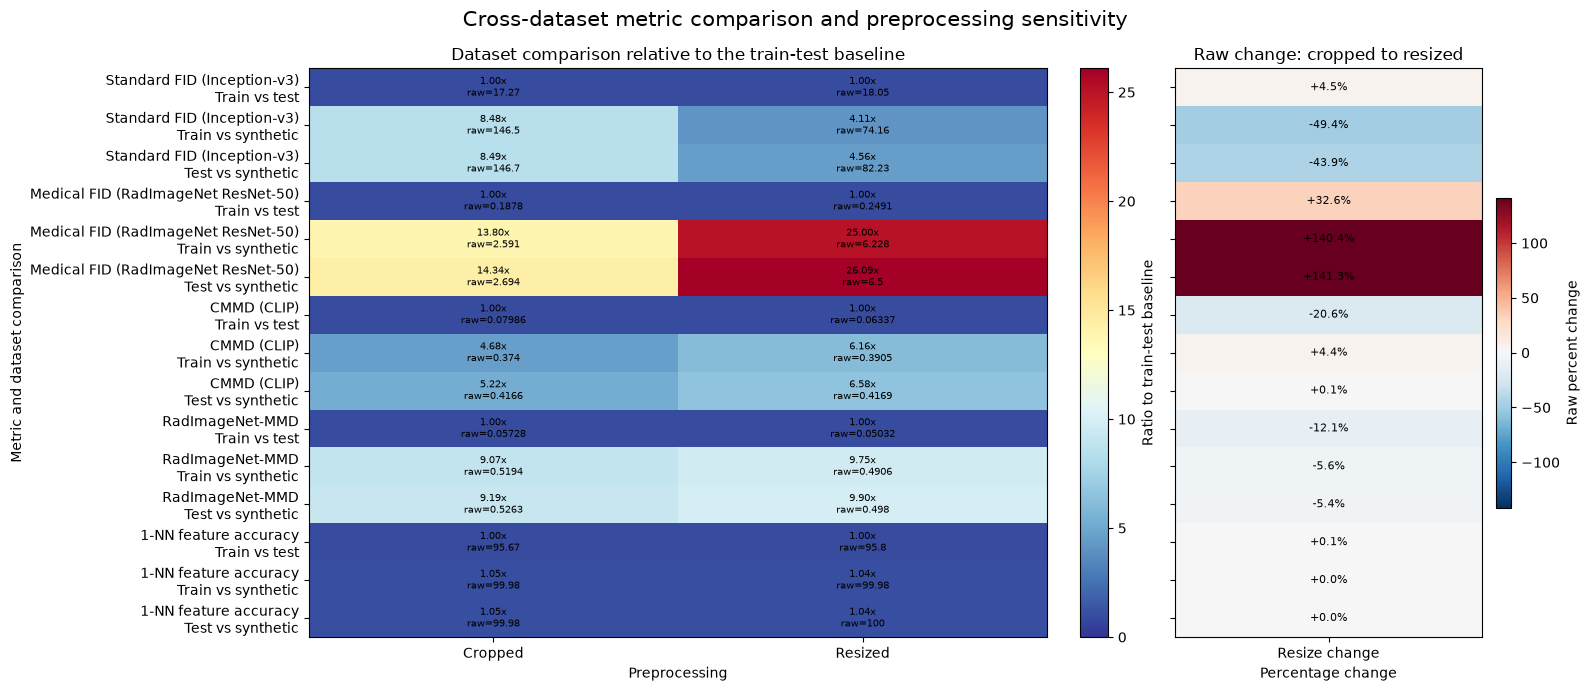

In [38]:
# Compare dataset relationships and the effect of spatial preprocessing.
# The left panel normalizes each metric to its train-test baseline because the
# metrics use different units. Raw values are included in each cell as a check.
comparison_plot_data = metric_comparison_statistics.dropna(
    subset=["Value (cropped)", "Value (resized)"]
).copy()

baseline_values = (
    comparison_plot_data[comparison_plot_data["Comparison"] == "train-test"]
    .set_index("Metric")[["Value (cropped)", "Value (resized)"]]
    .rename(
        columns={
            "Value (cropped)": "Baseline (cropped)",
            "Value (resized)": "Baseline (resized)",
        }
    )
)
comparison_plot_data = comparison_plot_data.join(baseline_values, on="Metric")
comparison_plot_data["Relative (cropped)"] = (
    comparison_plot_data["Value (cropped)"]
    / comparison_plot_data["Baseline (cropped)"]
)
comparison_plot_data["Relative (resized)"] = (
    comparison_plot_data["Value (resized)"]
    / comparison_plot_data["Baseline (resized)"]
)
comparison_plot_data["Resize change (%)"] = (
    (comparison_plot_data["Value (resized)"] - comparison_plot_data["Value (cropped)"])
    / comparison_plot_data["Value (cropped)"]
    * 100
)

metric_order = list(comparison_metric_info)
comparison_order_for_plot = ["train-test", "train-synth", "test-synth"]
comparison_labels = {
    "train-test": "Train vs test",
    "train-synth": "Train vs synthetic",
    "test-synth": "Test vs synthetic",
}

relative_rows = []
raw_rows = []
resize_rows = []
relative_labels = []
resize_labels = []
for metric in metric_order:
    metric_rows = comparison_plot_data[comparison_plot_data["Metric"] == metric]
    if metric_rows.empty:
        continue
    for comparison in comparison_order_for_plot:
        row = metric_rows[metric_rows["Comparison"] == comparison]
        if row.empty:
            continue
        row = row.iloc[0]
        relative_rows.append([row["Relative (cropped)"], row["Relative (resized)"]])
        raw_rows.append([row["Value (cropped)"], row["Value (resized)"]])
        resize_rows.append([row["Resize change (%)"]])
        relative_labels.append(f"{metric}\n{comparison_labels[comparison]}")
        resize_labels.append(f"{metric}\n{comparison_labels[comparison]}")

relative_matrix = np.asarray(relative_rows, dtype=float)
raw_matrix = np.asarray(raw_rows, dtype=float)
resize_matrix = np.asarray(resize_rows, dtype=float)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, max(7, 0.42 * len(relative_labels))),
    gridspec_kw={"width_ratios": [2.4, 1]},
)

relative_image = axes[0].imshow(
    relative_matrix,
    aspect="auto",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=max(2, np.nanmax(relative_matrix)),
)
axes[0].set_title("Dataset comparison relative to the train-test baseline")
axes[0].set_xticks([0, 1], labels=["Cropped", "Resized"])
axes[0].set_yticks(range(len(relative_labels)), labels=relative_labels)
axes[0].set_xlabel("Preprocessing")
axes[0].set_ylabel("Metric and dataset comparison")

for row_index in range(relative_matrix.shape[0]):
    for column_index in range(relative_matrix.shape[1]):
        axes[0].text(
            column_index,
            row_index,
            f"{relative_matrix[row_index, column_index]:.2f}x\n"
            f"raw={raw_matrix[row_index, column_index]:.4g}",
            ha="center",
            va="center",
            fontsize=7,
        )

resize_image = axes[1].imshow(
    resize_matrix,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-max(50, np.nanmax(np.abs(resize_matrix))),
    vmax=max(50, np.nanmax(np.abs(resize_matrix))),
)
axes[1].set_title("Raw change: cropped to resized")
axes[1].set_xticks([0], labels=["Resize change"])
axes[1].set_yticks(range(len(resize_labels)), labels=resize_labels)
axes[1].set_xlabel("Percentage change")
axes[1].tick_params(axis="y", labelleft=False)

for row_index in range(resize_matrix.shape[0]):
    axes[1].text(
        0,
        row_index,
        f"{resize_matrix[row_index, 0]:+.1f}%",
        ha="center",
        va="center",
        fontsize=8,
    )

fig.colorbar(relative_image, ax=axes[0], fraction=0.046, pad=0.04, label="Ratio to train-test baseline")
fig.colorbar(resize_image, ax=axes[1], fraction=0.046, pad=0.04, label="Raw percent change")
fig.suptitle("Cross-dataset metric comparison and preprocessing sensitivity", fontsize=15)
plt.tight_layout()
plt.show()


#### 1.3 Model performance statistics

LIST ALL TABLES THAT CAN BE FOUND IN THIS SECTION HERE

In [6]:
# Section for RadImageNet embedding visualization (?)

### 2 Visualization

 real and synthetic BRAVO slices together with their segmentation masks. Each selected case is shown as three panels: the BRAVO image, the image with the segmentation contour overlaid, and the segmentation mask. Selection can be random and reproducible or manually specified by dataset index.

In [7]:
def _remove_modality_suffix(filename, modality):
    """Return a filename stem without NIfTI and modality suffixes."""
    stem = filename.replace(".nii.gz", "").replace(".nii", "")
    for suffix in (f"_{modality}", f".{modality}"):
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
    return stem

def collect_bravo_seg_pairs(data_dir, modality="bravo"):
    """Collect and validate BRAVO/mask pairs from nested or flat layouts."""
    data_dir = Path(data_dir)
    image_files = sorted(data_dir.glob(f"**/{modality}/*.nii*"))
    mask_files = sorted(data_dir.glob("**/seg/*.nii*"))

    images = {}
    for image_path in image_files:
        relative = image_path.relative_to(data_dir)
        group = relative.parts[-3] if len(relative.parts) >= 3 else "flat"
        key = (group, _remove_modality_suffix(image_path.name, modality))
        images[key] = image_path

    masks = {}
    for mask_path in mask_files:
        relative = mask_path.relative_to(data_dir)
        group = relative.parts[-3] if len(relative.parts) >= 3 else "flat"
        key = (group, _remove_modality_suffix(mask_path.name, "seg"))
        masks[key] = mask_path

    missing_masks = sorted(set(images) - set(masks))
    missing_images = sorted(set(masks) - set(images))
    if missing_masks or missing_images:
        raise ValueError(
            f"Could not pair BRAVO and segmentation files in {data_dir}. "
            f"Missing masks: {len(missing_masks)}; missing images: {len(missing_images)}."
        )

    return [
        {"image": images[key], "mask": masks[key], "key": key}
        for key in sorted(images)
    ]

def _display_range(image):
    """Choose a stable display range while ignoring empty background."""
    nonzero = image[np.isfinite(image) & (image != 0)]
    if nonzero.size == 0:
        return float(np.nanmin(image)), float(np.nanmax(image))
    return tuple(np.percentile(nonzero, (1, 99)))

In [8]:
def _select_cases(cases, count, selection, indices, seed):
    if indices is not None:
        selected_indices = list(indices)
        invalid = [index for index in selected_indices if index < 0 or index >= len(cases)]
        if invalid:
            raise IndexError(f"Selected indices out of range: {invalid}")
    elif selection == "random":
        if count < 1:
            raise ValueError("count must be at least 1")
        if count > len(cases):
            raise ValueError(f"Requested {count} cases, but only {len(cases)} are available.")
        rng = random.Random(seed)
        selected_indices = sorted(rng.sample(range(len(cases)), count))
    elif selection == "first":
        selected_indices = list(range(min(count, len(cases))))
    else:
        raise ValueError("selection must be 'random' or 'first' when indices are not provided")

    return [(index, cases[index]) for index in selected_indices]

def _load_case(case):
    image = np.squeeze(nib.load(case["image"]).get_fdata())
    mask = np.squeeze(nib.load(case["mask"]).get_fdata())
    if image.ndim != 2 or mask.ndim != 2:
        raise ValueError(
            f"Expected 2D files, got image shape {image.shape} and mask shape {mask.shape} "
            f"for {case['image'].name}."
        )
    if image.shape != mask.shape:
        raise ValueError(
            f"Image/mask shape mismatch for {case['image'].name}: "
            f"{image.shape} versus {mask.shape}."
        )
    return image, mask

def show_dataset_cases(cases, selected_cases, dataset_name, figsize_per_case=(12, 3.6)):
    """Plot BRAVO, contour overlay, and mask for selected cases."""
    rows = len(selected_cases)
    fig, axes = plt.subplots(
        rows,
        3,
        figsize=(figsize_per_case[0], figsize_per_case[1] * rows),
        squeeze=False,
    )
    fig.suptitle(f"{dataset_name} BRAVO and segmentation examples", fontsize=15)

    for row, (index, case) in enumerate(selected_cases):
        image, mask = _load_case(case)
        vmin, vmax = _display_range(image)
        binary_mask = mask > 0

        axes[row, 0].imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"BRAVO | index {index}")

        axes[row, 1].imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
        if binary_mask.any():
            axes[row, 1].contour(binary_mask, levels=[0.5], colors="red", linewidths=1.5)
        axes[row, 1].set_title("BRAVO + mask contour")

        axes[row, 2].imshow(binary_mask, cmap="gray", interpolation="nearest")
        axes[row, 2].set_title("Segmentation mask")

        for column in range(3):
            axes[row, column].axis("off")

        print(f"{dataset_name} index {index}: {case['image']}")
        print(f"{dataset_name} mask {index}:  {case['mask']}")

    plt.tight_layout()
    plt.show()

In [9]:
def visualize_real_and_synthetic(
    real_dir,
    synthetic_dir,
    count=3,
    selection="random",
    real_indices=None,
    synthetic_indices=None,
    seed=42,
):
    """Display selected real and synthetic cases in separate figures.

    Use ``selection='random'`` for reproducible random samples, or pass
    ``real_indices`` and ``synthetic_indices`` for manual selection. Indices
    refer to the sorted validated pair lists printed below.
    """
    real_cases = collect_bravo_seg_pairs(real_dir)
    synthetic_cases = collect_bravo_seg_pairs(synthetic_dir)
    print(f"Validated pairs: real={len(real_cases)}, synthetic={len(synthetic_cases)}")

    real_selected = _select_cases(
        real_cases, count, selection, real_indices, seed
    )
    synthetic_selected = _select_cases(
        synthetic_cases, count, selection, synthetic_indices, seed + 1
    )

    show_dataset_cases(real_cases, real_selected, "Real")
    show_dataset_cases(synthetic_cases, synthetic_selected, "Synthetic")

Validated pairs: real=3823, synthetic=37624
Real index 102: ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_014\bravo\Mets_014_slice107_bravo.nii.gz
Real mask 102:  ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_014\seg\Mets_014_slice107_seg.nii.gz
Real index 456: ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_036\bravo\Mets_036_slice108_bravo.nii.gz
Real mask 456:  ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_036\seg\Mets_036_slice108_seg.nii.gz
Real index 2619: ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_189\bravo\Mets_189_slice120_bravo.nii.gz
Real mask 2619:  ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_189\seg\Mets_189_slice120_seg.nii.gz


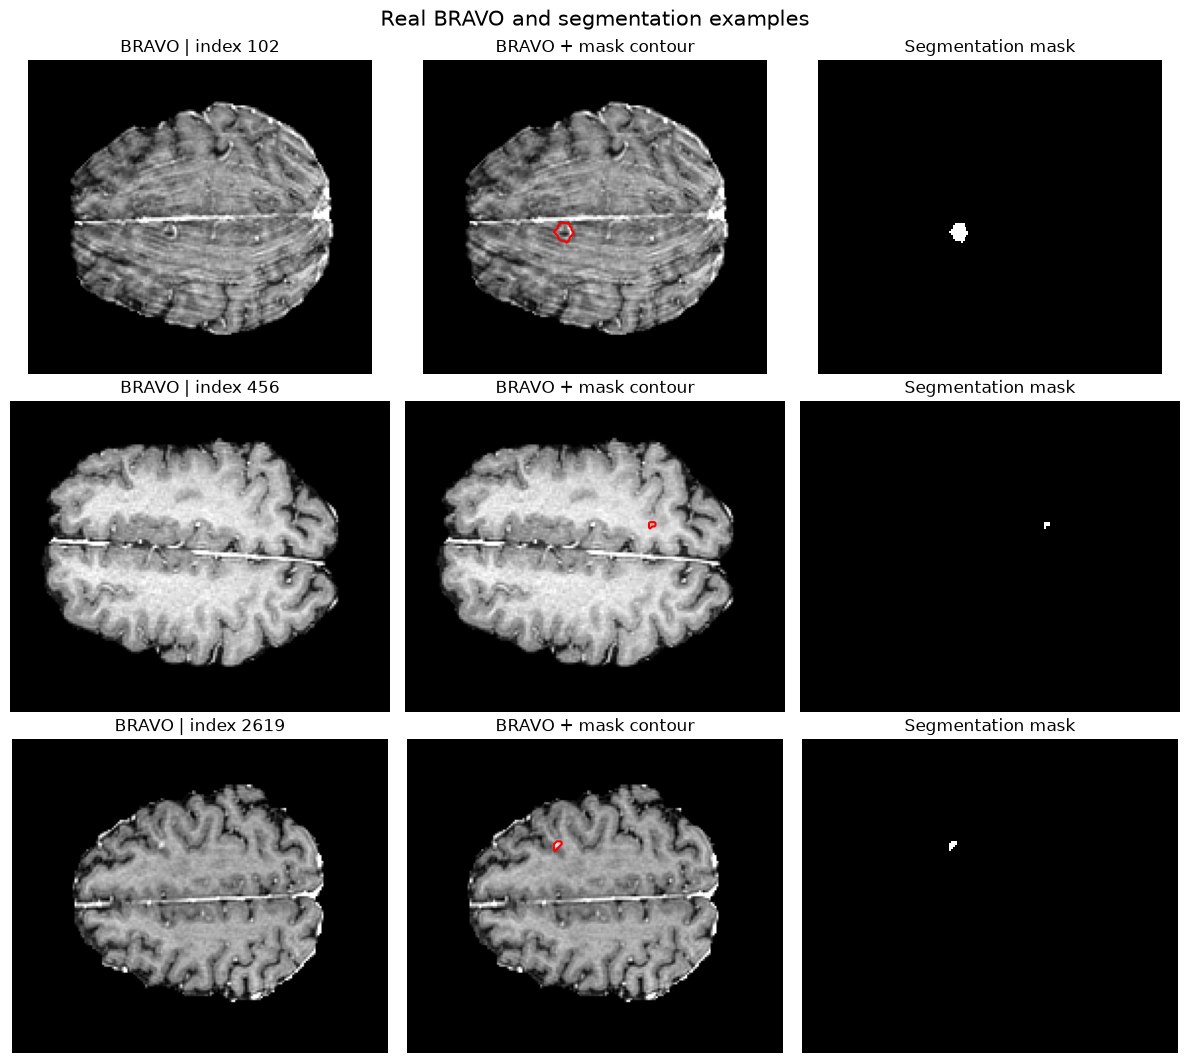

Synthetic index 2526: ..\processed_data\Synthetic_data_2d_all\bravo\1816.bravo.nii.gz
Synthetic mask 2526:  ..\processed_data\Synthetic_data_2d_all\seg\1816.seg.nii.gz
Synthetic index 9432: ..\processed_data\Synthetic_data_2d_all\bravo\file_2657.bravo.nii.gz
Synthetic mask 9432:  ..\processed_data\Synthetic_data_2d_all\seg\file_2657.seg.nii.gz
Synthetic index 18748: ..\processed_data\Synthetic_data_2d_all\bravo\file_3_4370.bravo.nii.gz
Synthetic mask 18748:  ..\processed_data\Synthetic_data_2d_all\seg\file_3_4370.seg.nii.gz


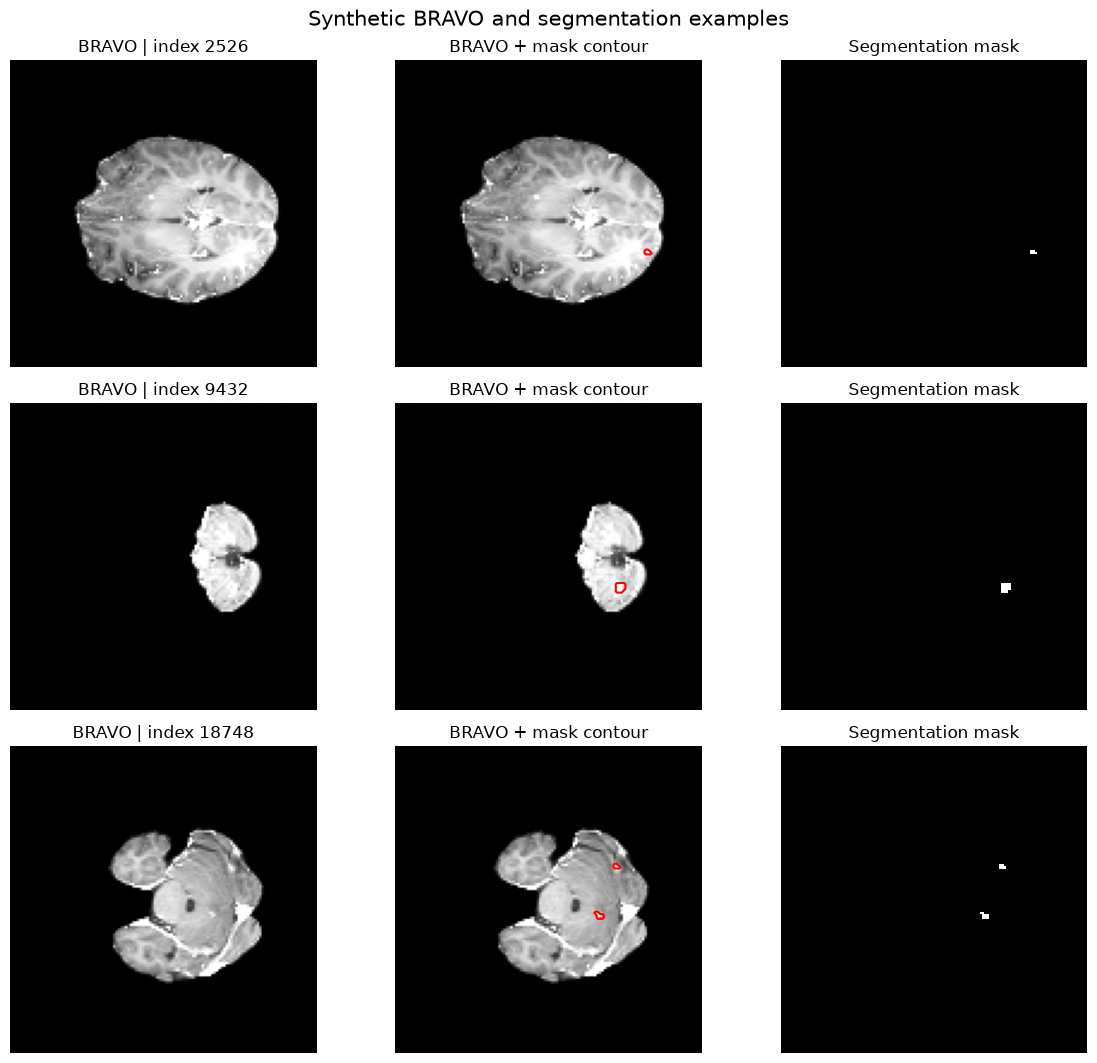

'\nvisualize_real_and_synthetic(\n    real_dir="../processed_data/StanfordSkullStripped_1mm_metsonly/train",\n    synthetic_dir="../processed_data/Synthetic_data_2d_all",\n    count=3,\n    real_indices=[0, 10, 25],\n    synthetic_indices=[0, 10, 25],\n)\n'

In [12]:
# Example 1: reproducible random visualization.
visualize_real_and_synthetic(
    real_dir="../processed_data/StanfordSkullStripped_1mm_metsonly/train",
    synthetic_dir="../processed_data/Synthetic_data_2d_all",
    count=3,
    selection="random",
    seed=42,
)

# Example 2: manual selection by sorted validated-pair index.
"""
visualize_real_and_synthetic(
    real_dir="../processed_data/StanfordSkullStripped_1mm_metsonly/train",
    synthetic_dir="../processed_data/Synthetic_data_2d_all",
    count=3,
    real_indices=[0, 10, 25],
    synthetic_indices=[0, 10, 25],
)
"""

In [13]:
def _transform_for_visualization(array, transform_mode, target_size, interpolation="bilinear"):
    """Apply only the selected spatial transform to a 2D array."""
    if transform_mode not in {"original", "resize", "pad_crop"}:
        raise ValueError("transform_mode must be 'original', 'resize', or 'pad_crop'")

    array = np.asarray(array)
    if array.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {array.shape}")
    if transform_mode == "original":
        return array.copy()

    channel_first = array[None, ...]
    if transform_mode == "resize":
        transformed = Resize(
            spatial_size=target_size,
            mode=interpolation,
        )(channel_first)
    else:
        transformed = ResizeWithPadOrCrop(
            spatial_size=target_size,
            mode="constant",
        )(channel_first)
    return np.asarray(transformed).squeeze(0)

def _visualization_display_range(image, display_range):
    """Return plotting limits without changing the image array."""
    if display_range == "raw":
        return None
    if display_range == "percentile":
        return _display_range(image)
    raise ValueError("display_range must be 'raw' or 'percentile'")

In [14]:
def show_spatial_comparison(
    cases,
    selected_cases,
    dataset_name,
    transform_mode="pad_crop",
    target_size=(256, 256),
    display_range="raw",
    figsize_per_case=(16, 3.8),
):
    """Compare stored images with one selected spatial preprocessing mode."""
    rows = len(selected_cases)
    fig, axes = plt.subplots(
        rows,
        4,
        figsize=(figsize_per_case[0], figsize_per_case[1] * rows),
        squeeze=False,
    )
    fig.suptitle(
        f"{dataset_name}: original vs {transform_mode} at {target_size} "
        f"(display range: {display_range})",
        fontsize=15,
    )

    for row, (index, case) in enumerate(selected_cases):
        image, mask = _load_case(case)
        transformed_image = _transform_for_visualization(
            image, transform_mode, target_size, interpolation="bilinear"
        )
        transformed_mask = _transform_for_visualization(
            mask, transform_mode, target_size, interpolation="nearest"
        ) > 0.5
        vmin, vmax = _visualization_display_range(image, display_range) or (None, None)

        axes[row, 0].imshow(image, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
        axes[row, 0].set_title(f"Original {image.shape}")

        axes[row, 1].imshow(
            transformed_image,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        axes[row, 1].set_title(f"{transform_mode} {transformed_image.shape}")

        axes[row, 2].imshow(
            transformed_image,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        if transformed_mask.any():
            axes[row, 2].contour(transformed_mask, levels=[0.5], colors="red", linewidths=1.5)
        axes[row, 2].set_title("Transformed + mask contour")

        axes[row, 3].imshow(transformed_mask, cmap="gray", interpolation="nearest")
        axes[row, 3].set_title("Transformed mask")

        for column in range(4):
            axes[row, column].axis("off")

        print(
            f"{dataset_name} index {index}: original {image.shape} -> "
            f"{transform_mode} {transformed_image.shape}"
        )
        print(f"{dataset_name} image: {case['image']}")
        print(f"{dataset_name} mask:  {case['mask']}")

    plt.tight_layout()
    plt.show()

In [15]:
def visualize_spatial_comparison(
    real_dir,
    synthetic_dir,
    count=3,
    selection="random",
    real_indices=None,
    synthetic_indices=None,
    seed=42,
    transform_mode="pad_crop",
    target_size=(256, 256),
    display_range="raw",
):
    """Visualize real and synthetic cases with an explicit spatial mode."""
    if transform_mode not in {"original", "resize", "pad_crop"}:
        raise ValueError("transform_mode must be 'original', 'resize', or 'pad_crop'")

    real_cases = collect_bravo_seg_pairs(real_dir)
    synthetic_cases = collect_bravo_seg_pairs(synthetic_dir)
    real_selected = _select_cases(real_cases, count, selection, real_indices, seed)
    synthetic_selected = _select_cases(
        synthetic_cases, count, selection, synthetic_indices, seed + 1
    )

    show_spatial_comparison(
        real_cases,
        real_selected,
        "Real",
        transform_mode=transform_mode,
        target_size=target_size,
        display_range=display_range,
    )
    show_spatial_comparison(
        synthetic_cases,
        synthetic_selected,
        "Synthetic",
        transform_mode=transform_mode,
        target_size=target_size,
        display_range=display_range,
    )

Real index 102: original (160, 176) -> resize (256, 256)
Real image: ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_014\bravo\Mets_014_slice107_bravo.nii.gz
Real mask:  ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_014\seg\Mets_014_slice107_seg.nii.gz
Real index 456: original (144, 176) -> resize (256, 256)
Real image: ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_036\bravo\Mets_036_slice108_bravo.nii.gz
Real mask:  ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_036\seg\Mets_036_slice108_seg.nii.gz
Real index 2619: original (160, 192) -> resize (256, 256)
Real image: ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_189\bravo\Mets_189_slice120_bravo.nii.gz
Real mask:  ..\processed_data\StanfordSkullStripped_1mm_metsonly\train\Mets_189\seg\Mets_189_slice120_seg.nii.gz


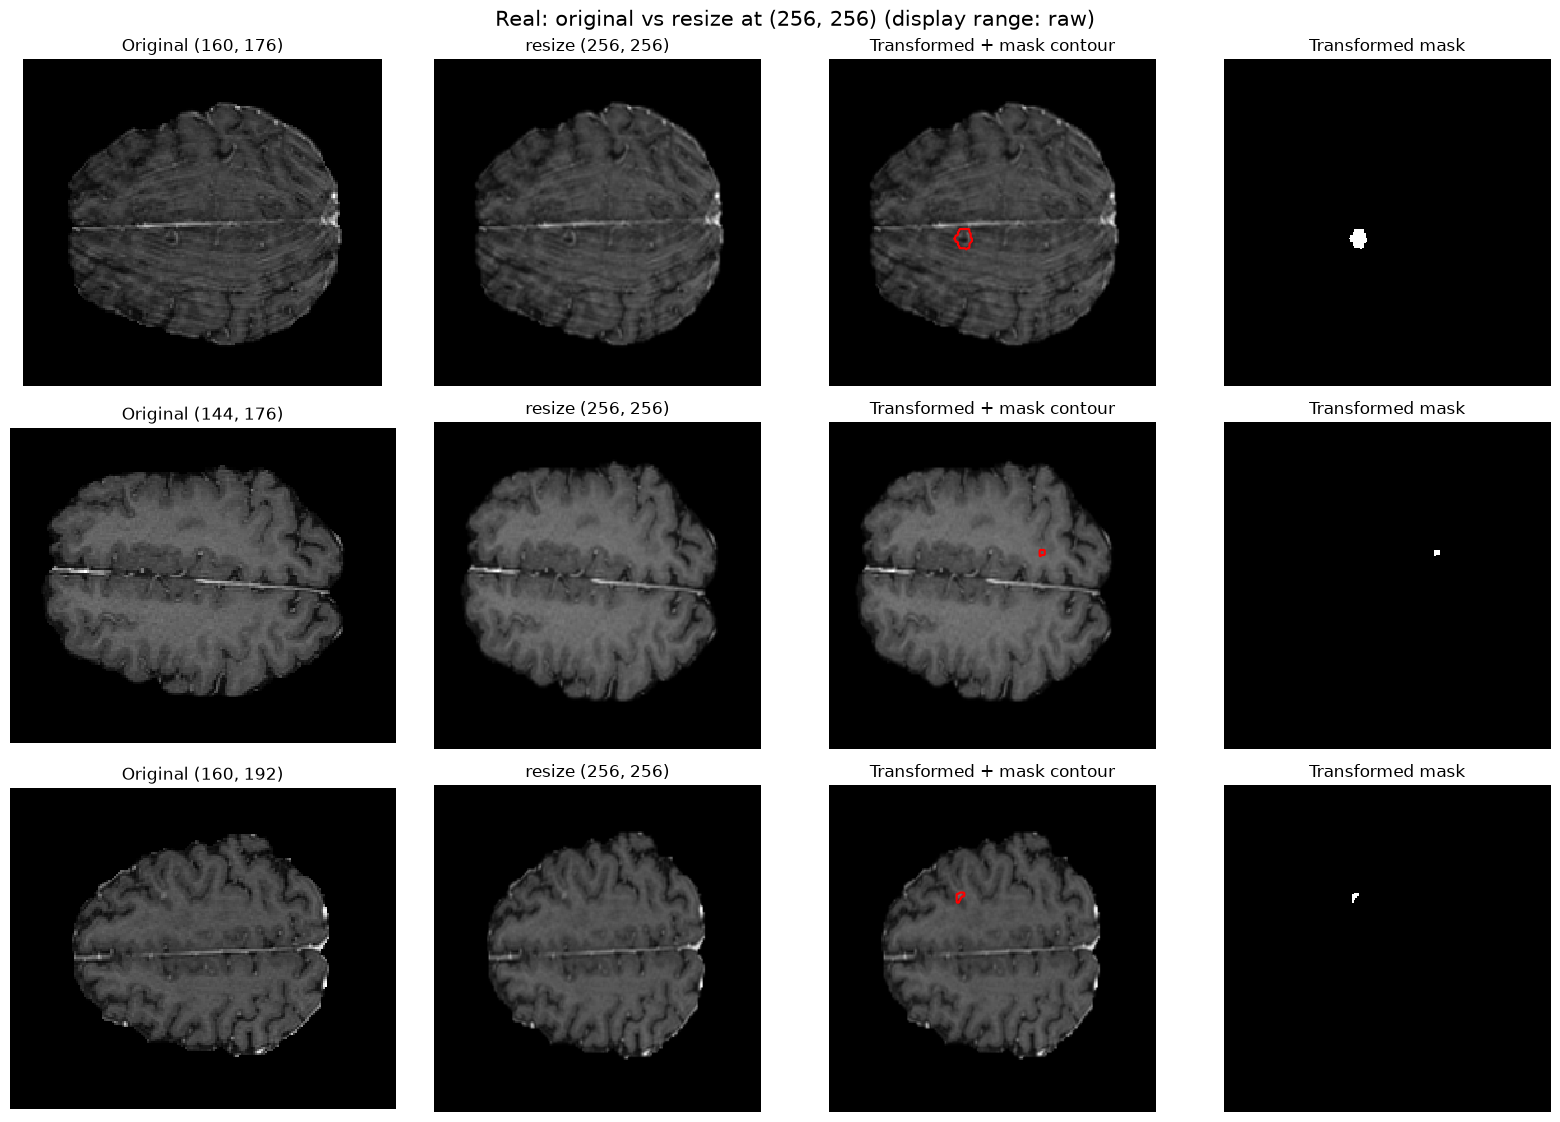

Synthetic index 2526: original (128, 128) -> resize (256, 256)
Synthetic image: ..\processed_data\Synthetic_data_2d_all\bravo\1816.bravo.nii.gz
Synthetic mask:  ..\processed_data\Synthetic_data_2d_all\seg\1816.seg.nii.gz
Synthetic index 9432: original (128, 128) -> resize (256, 256)
Synthetic image: ..\processed_data\Synthetic_data_2d_all\bravo\file_2657.bravo.nii.gz
Synthetic mask:  ..\processed_data\Synthetic_data_2d_all\seg\file_2657.seg.nii.gz
Synthetic index 18748: original (128, 128) -> resize (256, 256)
Synthetic image: ..\processed_data\Synthetic_data_2d_all\bravo\file_3_4370.bravo.nii.gz
Synthetic mask:  ..\processed_data\Synthetic_data_2d_all\seg\file_3_4370.seg.nii.gz


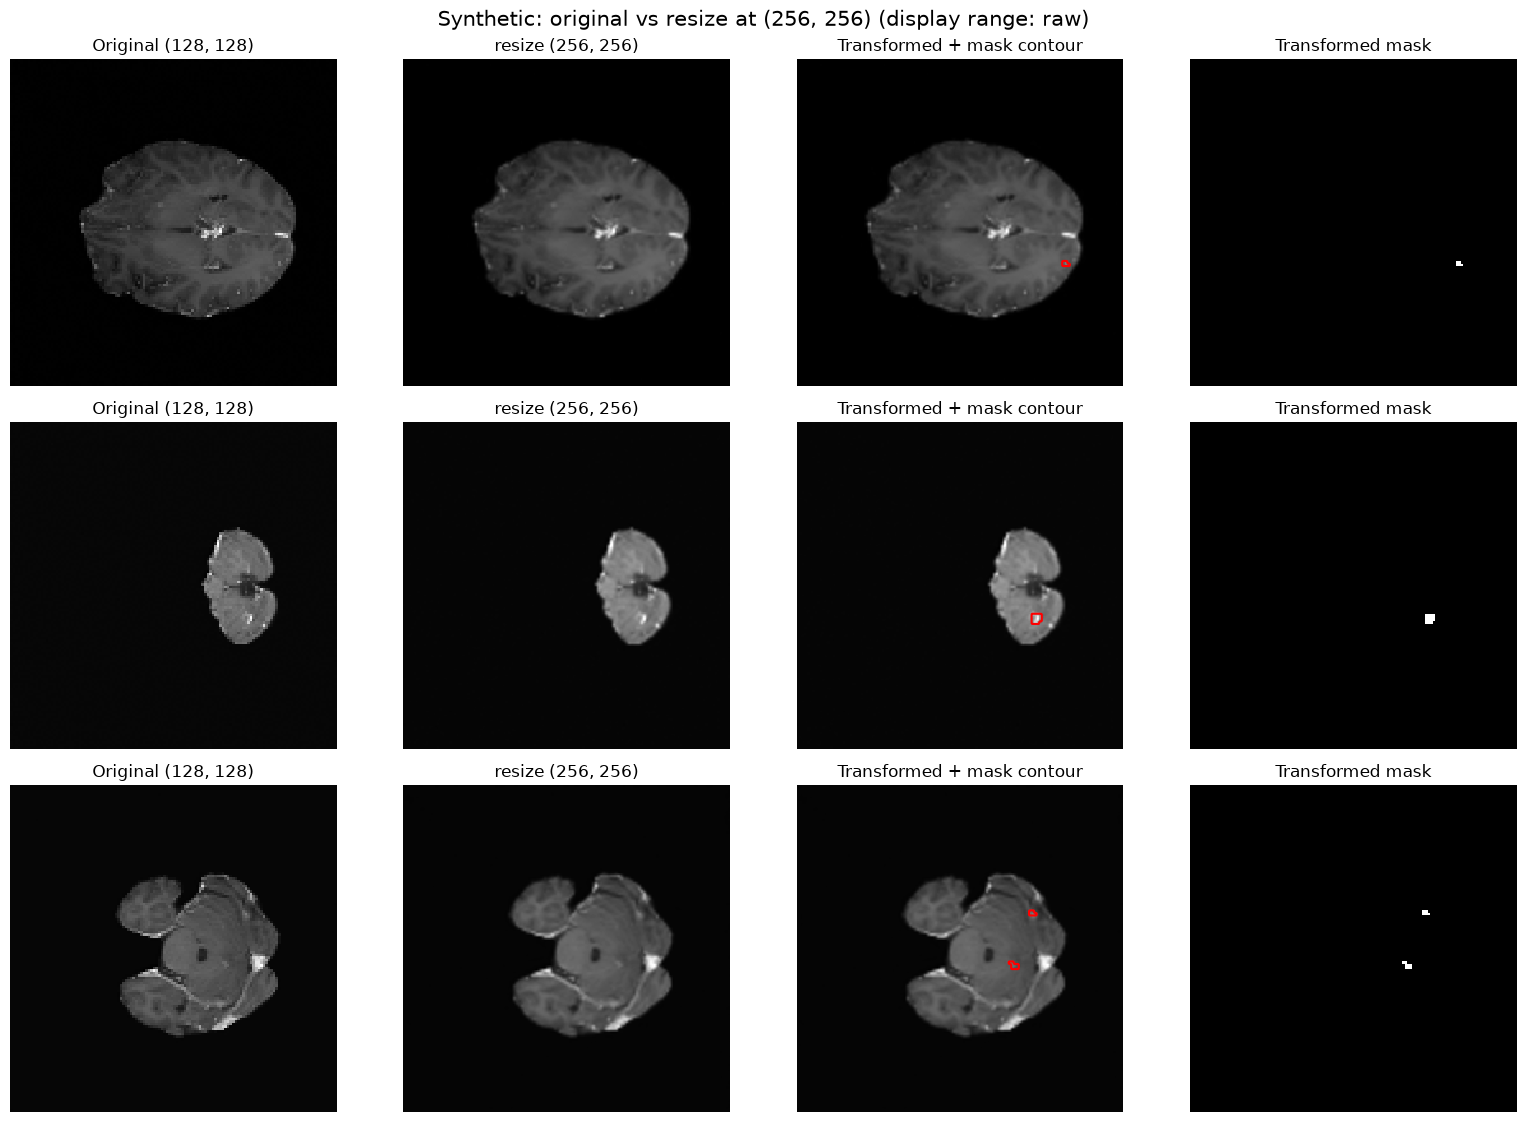

In [17]:
# Change only this value to compare the spatial preprocessing choices.
comparison_mode = "resize"  # "original", "resize", or "pad_crop"
visualize_spatial_comparison(
    real_dir="../processed_data/StanfordSkullStripped_1mm_metsonly/train",
    synthetic_dir="../processed_data/Synthetic_data_2d_all",
    count=3,
    selection="random",
    seed=42,
    transform_mode=comparison_mode,
    target_size=(256, 256),
    display_range="raw",  # Use "percentile" to match the earlier notebook plots.
)